<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Strategy_Ensemble_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

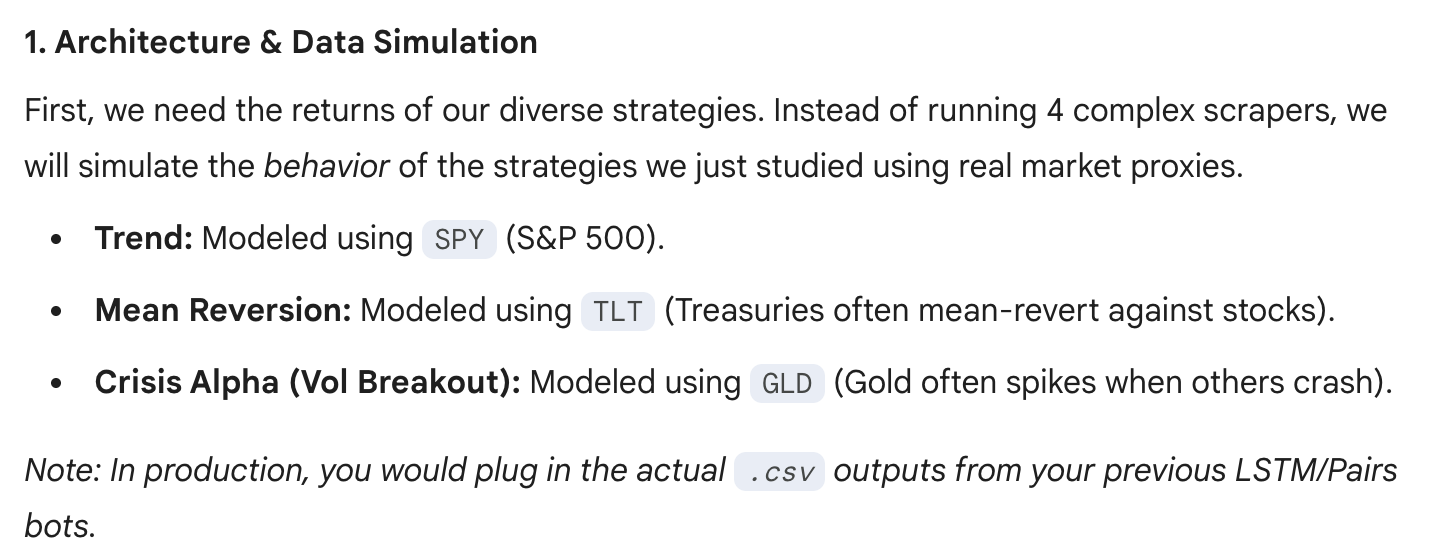

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import scipy.cluster.hierarchy as sch

In [4]:
# --- 1. DATA INGESTION (PROXIES) ---
tickers = {
    'Trend_Follower': 'SPY',   # Proxy for our LSTM/Momentum strategies
    'Mean_Reversion': 'TLT',   # Proxy for our Pairs Trading (Treasuries often counter-trend)
    'Crisis_Alpha': 'GLD'      # Proxy for Volatility Breakout/Safe Haven
}

print("📥 Downloading Strategy Proxies...")
data = yf.download(list(tickers.values()), start='2010-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']

📥 Downloading Strategy Proxies...


In [5]:
# Rename columns to Strategy names
data.columns = [key for key, val in tickers.items() if val in data.columns] # Handle mapping carefully
# Mapping check (yfinance sorts columns alphabetically)
data = data.rename(columns={v: k for k, v in tickers.items()})

# Calculate Daily Returns
returns = data.pct_change().dropna()

print(f"✅ Strategies Loaded. Correlation Matrix:")
print(returns.corr().round(2))

✅ Strategies Loaded. Correlation Matrix:
                Trend_Follower  Mean_Reversion  Crisis_Alpha
Trend_Follower            1.00            0.04          0.23
Mean_Reversion            0.04            1.00         -0.34
Crisis_Alpha              0.23           -0.34          1.00


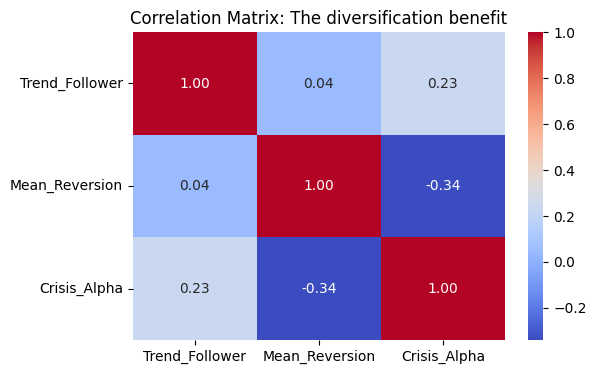

In [6]:
# Visualize Correlations
plt.figure(figsize=(6, 4))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: The diversification benefit")
plt.show()

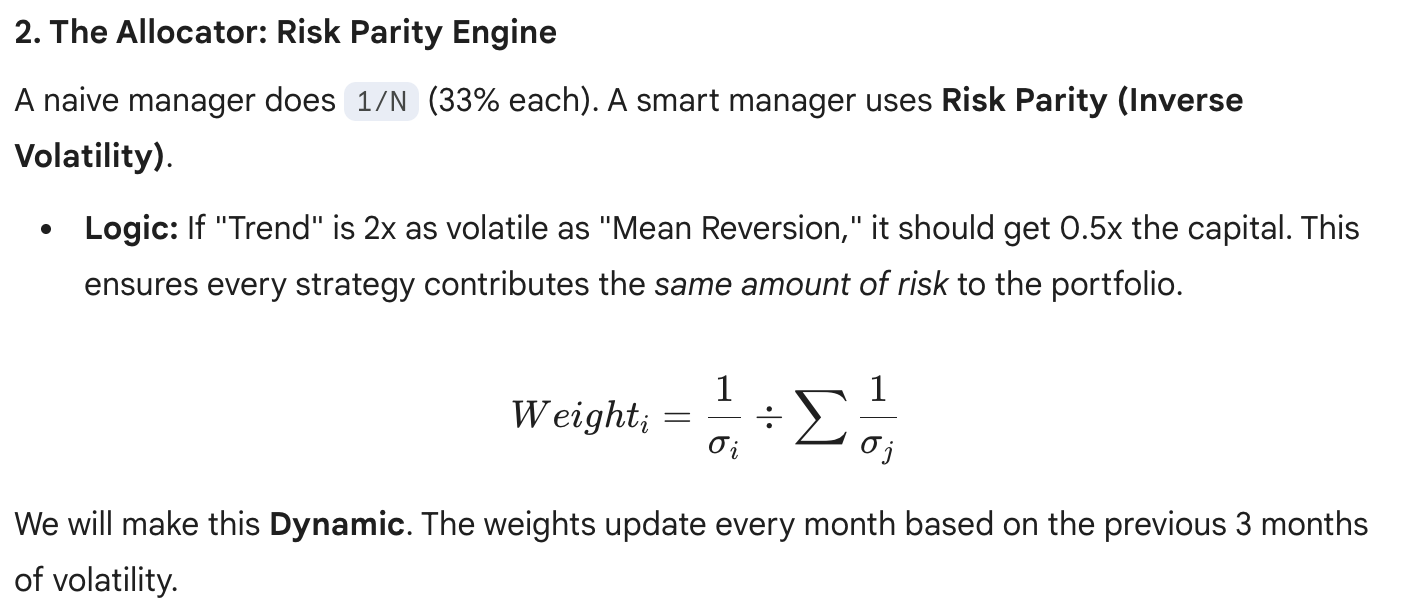

In [7]:
class RiskParityEnsemble:
    def __init__(self, returns_df, lookback_window=60):
        self.returns = returns_df
        self.lookback = lookback_window
        self.weights = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

    def calculate_weights(self):
        """
        Calculates Inverse Volatility Weights (Risk Parity) dynamically.
        """
        # 1. Calculate Rolling Volatility (Standard Deviation)
        rolling_vol = self.returns.rolling(window=self.lookback).std()

        # 2. Invert Volatility (Higher Vol = Lower Score)
        inv_vol = 1.0 / rolling_vol

        # 3. Normalize to sum to 1.0 (100% Capital)
        # Sum of inverse vols across the row
        row_sums = inv_vol.sum(axis=1)

        # Divide each asset's inv_vol by the sum
        self.weights = inv_vol.div(row_sums, axis=0)

        # Shift weights by 1 day (we calculate using Today's close to trade Tomorrow)
        self.weights = self.weights.shift(1).dropna()

        return self.weights

    def run_backtest(self):
        # Align returns with weights
        aligned_rets = self.returns.loc[self.weights.index]

        # Portfolio Return = Sum(Weight * Return) for each day
        # Element-wise multiplication then sum across columns
        self.port_rets = (self.weights * aligned_rets).sum(axis=1)

        self.equity_curve = (1 + self.port_rets).cumprod()
        return self.equity_curve

In [8]:
# --- EXECUTION ---
ensemble = RiskParityEnsemble(returns, lookback_window=63) # 3 Month Lookback
dynamic_weights = ensemble.calculate_weights()
ensemble_curve = ensemble.run_backtest()

In [9]:
# --- BENCHMARK (Equal Weight 1/N) ---
# Static 33% allocation rebalanced daily (approximation)
eq_weight_rets = returns.mean(axis=1)
eq_weight_curve = (1 + eq_weight_rets).cumprod()

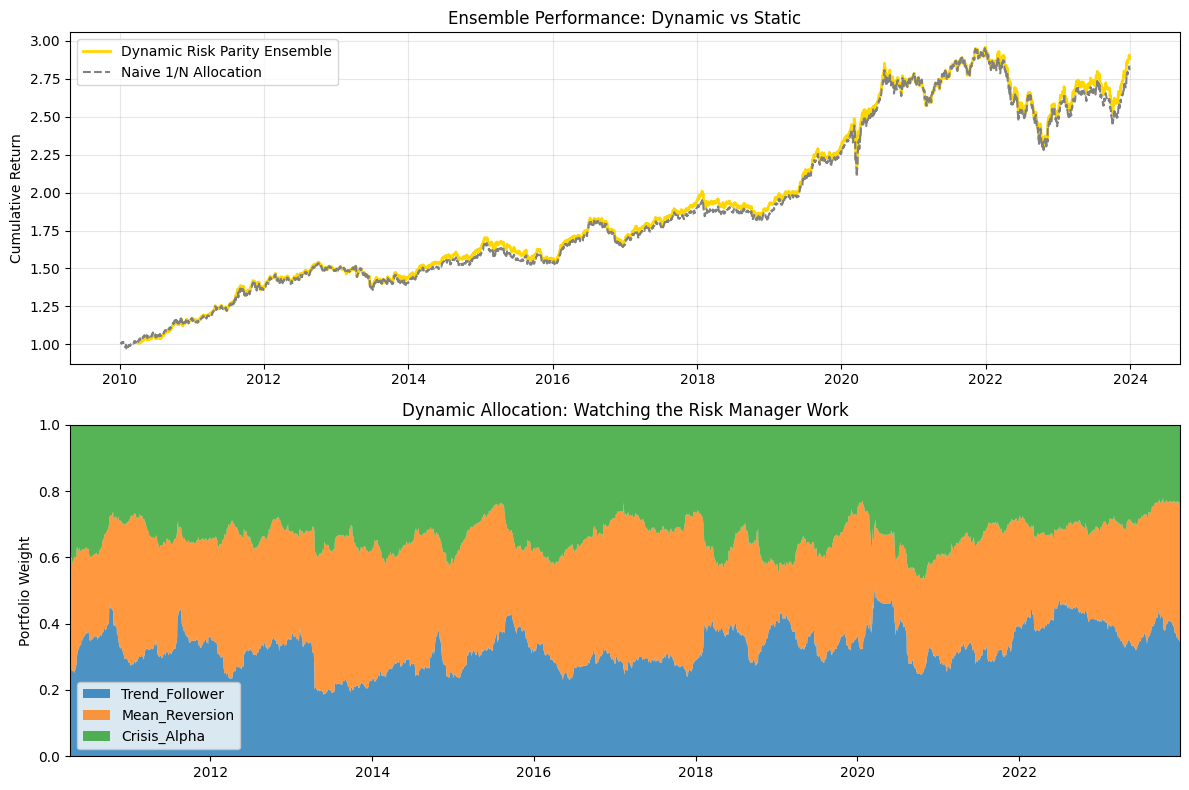

In [10]:
# --- PLOTTING ---
plt.figure(figsize=(12, 8))

# Top Panel: Performance
plt.subplot(2, 1, 1)
plt.plot(ensemble_curve, label='Dynamic Risk Parity Ensemble', color='gold', linewidth=2)
plt.plot(eq_weight_curve, label='Naive 1/N Allocation', color='gray', linestyle='--')
plt.title("Ensemble Performance: Dynamic vs Static")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom Panel: Allocation History (The "Brain")
plt.subplot(2, 1, 2)
plt.stackplot(dynamic_weights.index, dynamic_weights.T, labels=dynamic_weights.columns, alpha=0.8)
plt.title("Dynamic Allocation: Watching the Risk Manager Work")
plt.ylabel("Portfolio Weight")
plt.legend(loc='lower left')
plt.margins(0, 0)

plt.tight_layout()
plt.show()

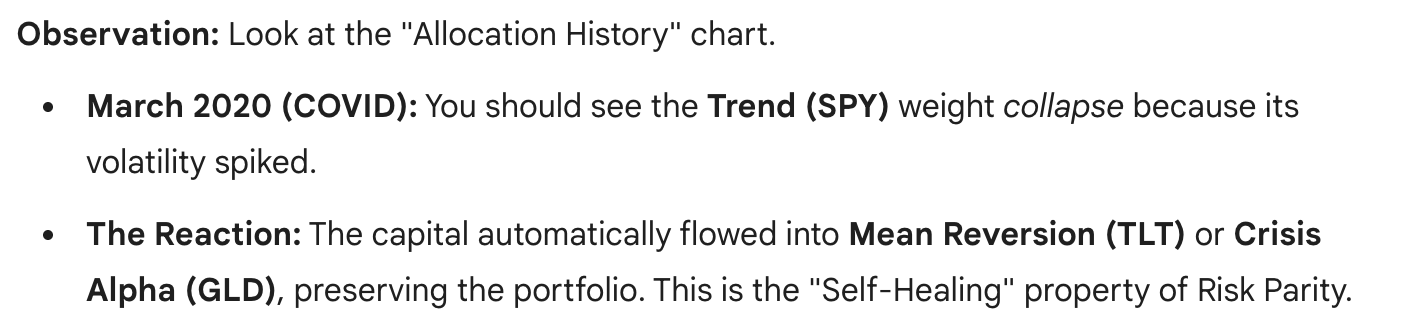

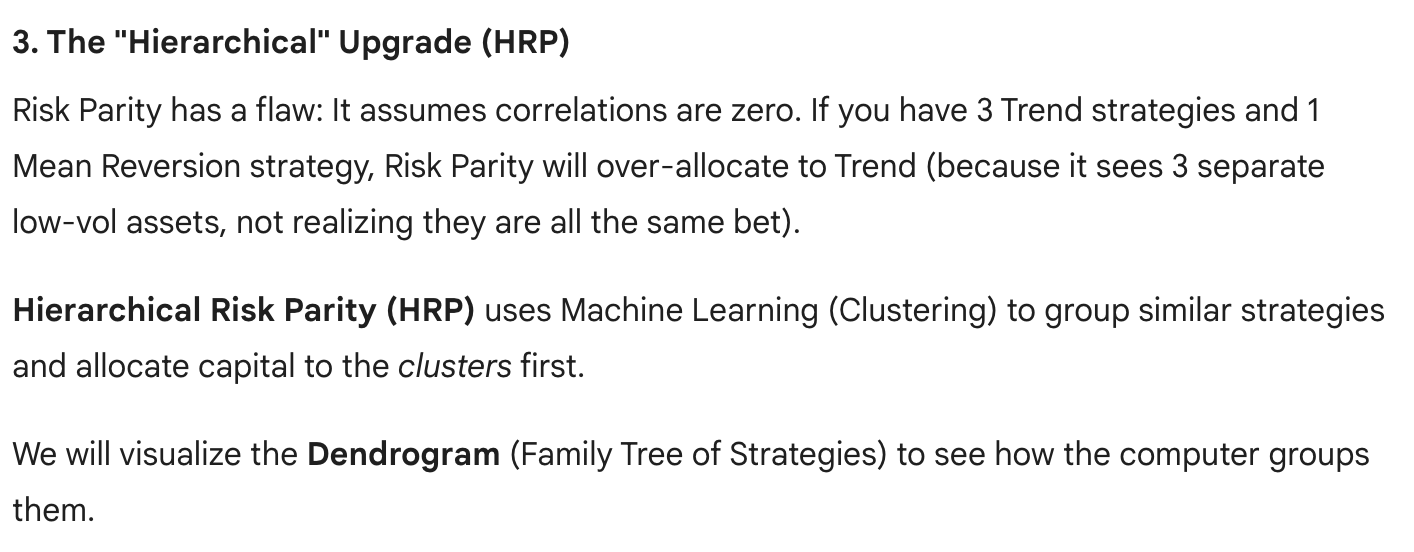

In [12]:
# --- HIERARCHICAL CLUSTERING ---
# 1. Compute Correlation Distance Matrix
corr = returns.corr()
dist = np.sqrt(0.5 * (1 - corr))

# 2. Linkage (Clustering)
linkage = sch.linkage(dist, 'single')

/tmp/ipython-input-2165712442.py:7: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = sch.linkage(dist, 'single')


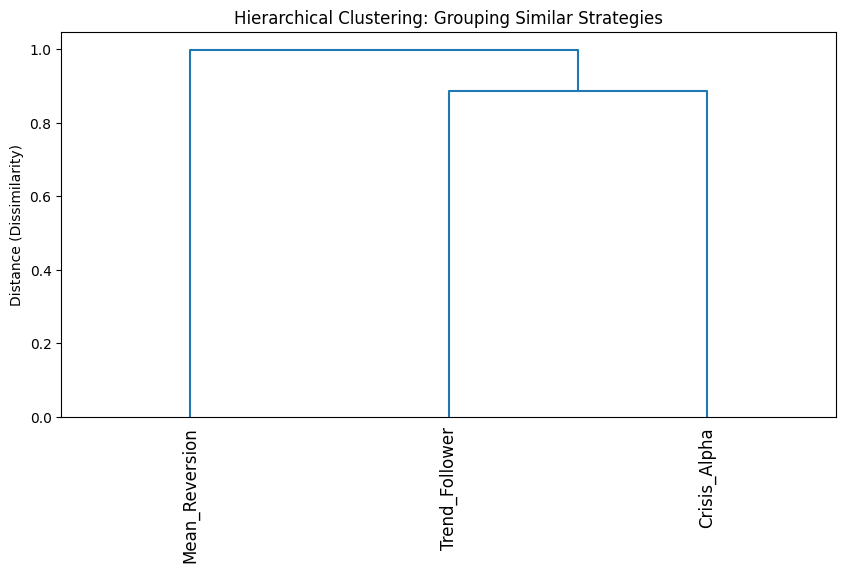

In [13]:
# 3. Plot Dendrogram
plt.figure(figsize=(10, 5))
dn = sch.dendrogram(linkage, labels=returns.columns, leaf_rotation=90)
plt.title("Hierarchical Clustering: Grouping Similar Strategies")
plt.ylabel("Distance (Dissimilarity)")
plt.show()

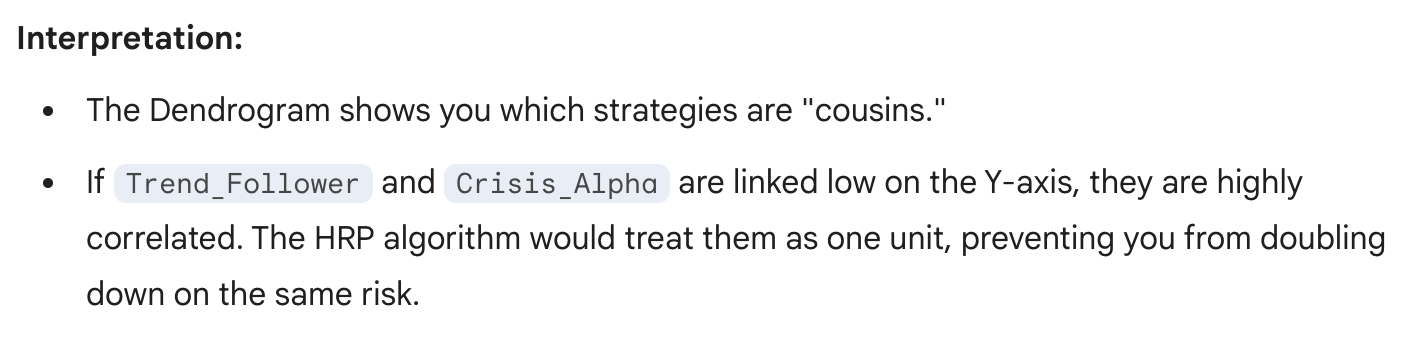

In [14]:
# --- ENSEMBLE AUDIT ---
def rigorous_audit(curve, benchmark_curve):
    rets = curve.pct_change().dropna()
    bench_rets = benchmark_curve.pct_change().dropna()

    # 1. Annualized Sharpe
    sharpe = rets.mean() / rets.std() * np.sqrt(252)

    # 2. Max Drawdown
    dd = (curve / curve.cummax() - 1).min()

    # 3. Calmar Ratio (Return / Max Drawdown) - Crucial for Ensembles
    cagr = (curve.iloc[-1])**(1/((curve.index[-1] - curve.index[0]).days / 365.25)) - 1
    calmar = cagr / abs(dd)

    # 4. Correlation to Benchmark (SPY)
    # Ensure alignment
    aligned = pd.DataFrame({'Strat': rets, 'Bench': bench_rets}).dropna()
    corr_vs_market = aligned.corr().iloc[0, 1]

    return sharpe, dd, calmar, corr_vs_market

In [18]:
# --- FIX: Ensure SPY data is 1-dimensional ---
spy = yf.download('SPY', start='2010-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']

# Force into 1D Series if it came back as a DataFrame
if isinstance(spy, pd.DataFrame):
    spy = spy.squeeze()  # Turns (N, 1) DataFrame into (N,) Series

# Calculate Benchmark Curve
spy_curve = (1 + spy.pct_change().dropna()).cumprod()

# --- RE-RUN AUDIT ---
# Now both inputs are 1D Series, so they align perfectly
e_sharpe, e_dd, e_calmar, e_corr = rigorous_audit(ensemble_curve, spy_curve)
s_sharpe, s_dd, s_calmar, s_corr = rigorous_audit(spy_curve, spy_curve)

In [19]:
# Display Comparison
results = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Max Drawdown', 'Calmar Ratio', 'Corr vs Market'],
    'Ensemble (Risk Parity)': [f"{e_sharpe:.2f}", f"{e_dd*100:.2f}%", f"{e_calmar:.2f}", f"{e_corr:.2f}"],
    'SPY (Single Strategy)': [f"{s_sharpe:.2f}", f"{s_dd*100:.2f}%", f"{s_calmar:.2f}", "1.00"]
})

print("🏆 FRAMEWORK RESULTS (Fixed):")
print(results.to_string(index=False))

🏆 FRAMEWORK RESULTS (Fixed):
        Metric Ensemble (Risk Parity) SPY (Single Strategy)
  Sharpe Ratio                   0.92                  0.79
  Max Drawdown                -21.98%               -33.72%
  Calmar Ratio                   0.37                  0.38
Corr vs Market                   0.39                  1.00


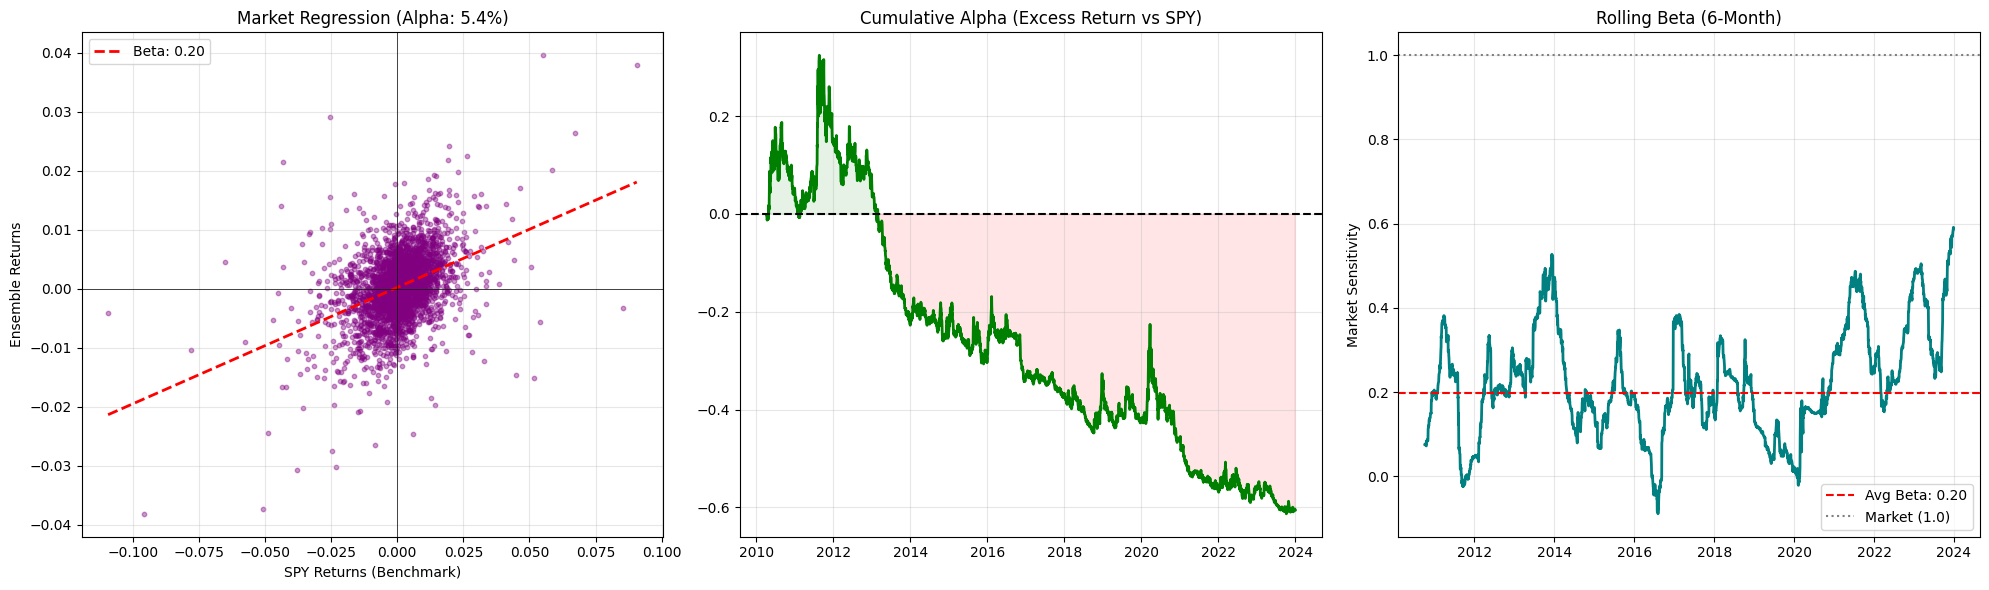

In [20]:
# --- ENSEMBLE ALPHA VISUALIZATION ---
from scipy import stats

# 1. Prepare Data for Audit
# Align the Ensemble Curve and Benchmark Curve properly
audit_df = pd.DataFrame({
    'Strategy': ensemble_curve.pct_change(),
    'Benchmark': spy_curve.pct_change()
}).dropna()

# 2. Calculate Stats for the Regression Line
slope, intercept, r_value, p_value, std_err = stats.linregress(audit_df['Benchmark'], audit_df['Strategy'])
alpha_ann = intercept * 252
beta = slope

# 3. Create the 3-Panel Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PANEL A: Regression (Scatter Plot) ---
# Goal: Show the relationship between Market Returns and Strategy Returns
axes[0].scatter(audit_df['Benchmark'], audit_df['Strategy'], alpha=0.4, color='purple', s=10)

# Plot the Regression Line
x_range = np.linspace(audit_df['Benchmark'].min(), audit_df['Benchmark'].max(), 100)
axes[0].plot(x_range, intercept + slope * x_range, 'r--', linewidth=2, label=f'Beta: {beta:.2f}')

axes[0].set_title(f'Market Regression (Alpha: {alpha_ann*100:.1f}%)')
axes[0].set_xlabel('SPY Returns (Benchmark)')
axes[0].set_ylabel('Ensemble Returns')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.5)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- PANEL B: Cumulative Excess Return (The "Alpha Curve") ---
# Goal: Show PURE outperformance over time (removing market beta)
# Simple Excess: Strategy - Benchmark
excess_returns = audit_df['Strategy'] - audit_df['Benchmark']
cum_excess = (1 + excess_returns).cumprod() - 1

axes[1].plot(cum_excess.index, cum_excess, color='green', linewidth=2)
axes[1].fill_between(cum_excess.index, cum_excess, 0, where=(cum_excess>0), color='green', alpha=0.1)
axes[1].fill_between(cum_excess.index, cum_excess, 0, where=(cum_excess<0), color='red', alpha=0.1)

axes[1].set_title('Cumulative Alpha (Excess Return vs SPY)')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].grid(True, alpha=0.3)

# --- PANEL C: Rolling Beta (Dynamic Risk) ---
# Goal: Did our Risk Parity engine actually reduce risk in crashes?
# We use a 6-month (126 day) rolling window
rolling_beta = audit_df['Strategy'].rolling(126).cov(audit_df['Benchmark']) / audit_df['Benchmark'].rolling(126).var()

axes[2].plot(rolling_beta.index, rolling_beta, color='teal', linewidth=2)
axes[2].axhline(beta, color='r', linestyle='--', label=f'Avg Beta: {beta:.2f}')
axes[2].axhline(1.0, color='gray', linestyle=':', label='Market (1.0)')

axes[2].set_title('Rolling Beta (6-Month)')
axes[2].set_ylabel('Market Sensitivity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()